In [1]:
import numpy as np 
import pandas as pd
from scipy.cluster import hierarchy 
from scipy.spatial import distance_matrix 
from matplotlib import pyplot as plt 
from sklearn.cluster import AgglomerativeClustering 

In [2]:
customer='customer.csv'
df=pd.read_csv(customer)
print("shape of dataset:",df.shape)
df.head(5)

shape of dataset: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<h2>Pre-processing</h2>

In [3]:
x = df[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
x[0:5]

array([[1, 'Male', 19, 15, 39],
       [2, 'Male', 21, 15, 81],
       [3, 'Female', 20, 16, 6],
       [4, 'Female', 23, 16, 77],
       [5, 'Female', 31, 17, 40]], dtype=object)

In [4]:
from sklearn import preprocessing
gender = preprocessing.LabelEncoder()
gender.fit(['Female','Male'])
x[:,1] = gender.transform(x[:,1]) 

In [5]:
x[0:5]

array([[1, 1, 19, 15, 39],
       [2, 1, 21, 15, 81],
       [3, 0, 20, 16, 6],
       [4, 0, 23, 16, 77],
       [5, 0, 31, 17, 40]], dtype=object)

### Normalization
**MinMaxScaler** transforms features by scaling each feature to a given range.<br/>
it is between zero and one.

In [6]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler()
x_mtx=min_max_scaler.fit_transform(x)
x_mtx[0:5]

array([[0.        , 1.        , 0.01923077, 0.        , 0.3877551 ],
       [0.00502513, 1.        , 0.05769231, 0.        , 0.81632653],
       [0.01005025, 0.        , 0.03846154, 0.00819672, 0.05102041],
       [0.01507538, 0.        , 0.09615385, 0.00819672, 0.7755102 ],
       [0.0201005 , 0.        , 0.25      , 0.01639344, 0.39795918]])

## Hierarchical Clustering

In [7]:
# calculate the distance matrix
from sklearn.metrics.pairwise import euclidean_distances
dist_matrix = euclidean_distances(x_mtx,x_mtx) 
print(dist_matrix)

[[0.         0.43032315 1.055428   ... 1.41345435 1.44858323 1.49877657]
 [0.43032315 0.         1.25942674 ... 1.35931186 1.56141421 1.42138915]
 [1.055428   1.25942674 0.         ... 1.818757   1.73838961 1.902105  ]
 ...
 [1.41345435 1.35931186 1.818757   ... 0.         0.57852001 0.13469899]
 [1.44858323 1.56141421 1.73838961 ... 0.57852001 0.         0.66439853]
 [1.49877657 1.42138915 1.902105   ... 0.13469899 0.66439853 0.        ]]


In [8]:
Z_using_dist_matrix = hierarchy.linkage(dist_matrix, 'complete')

C:\Users\bgc\AppData\Local\Temp/ipykernel_11240/1633147189.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z_using_dist_matrix = hierarchy.linkage(dist_matrix, 'complete')


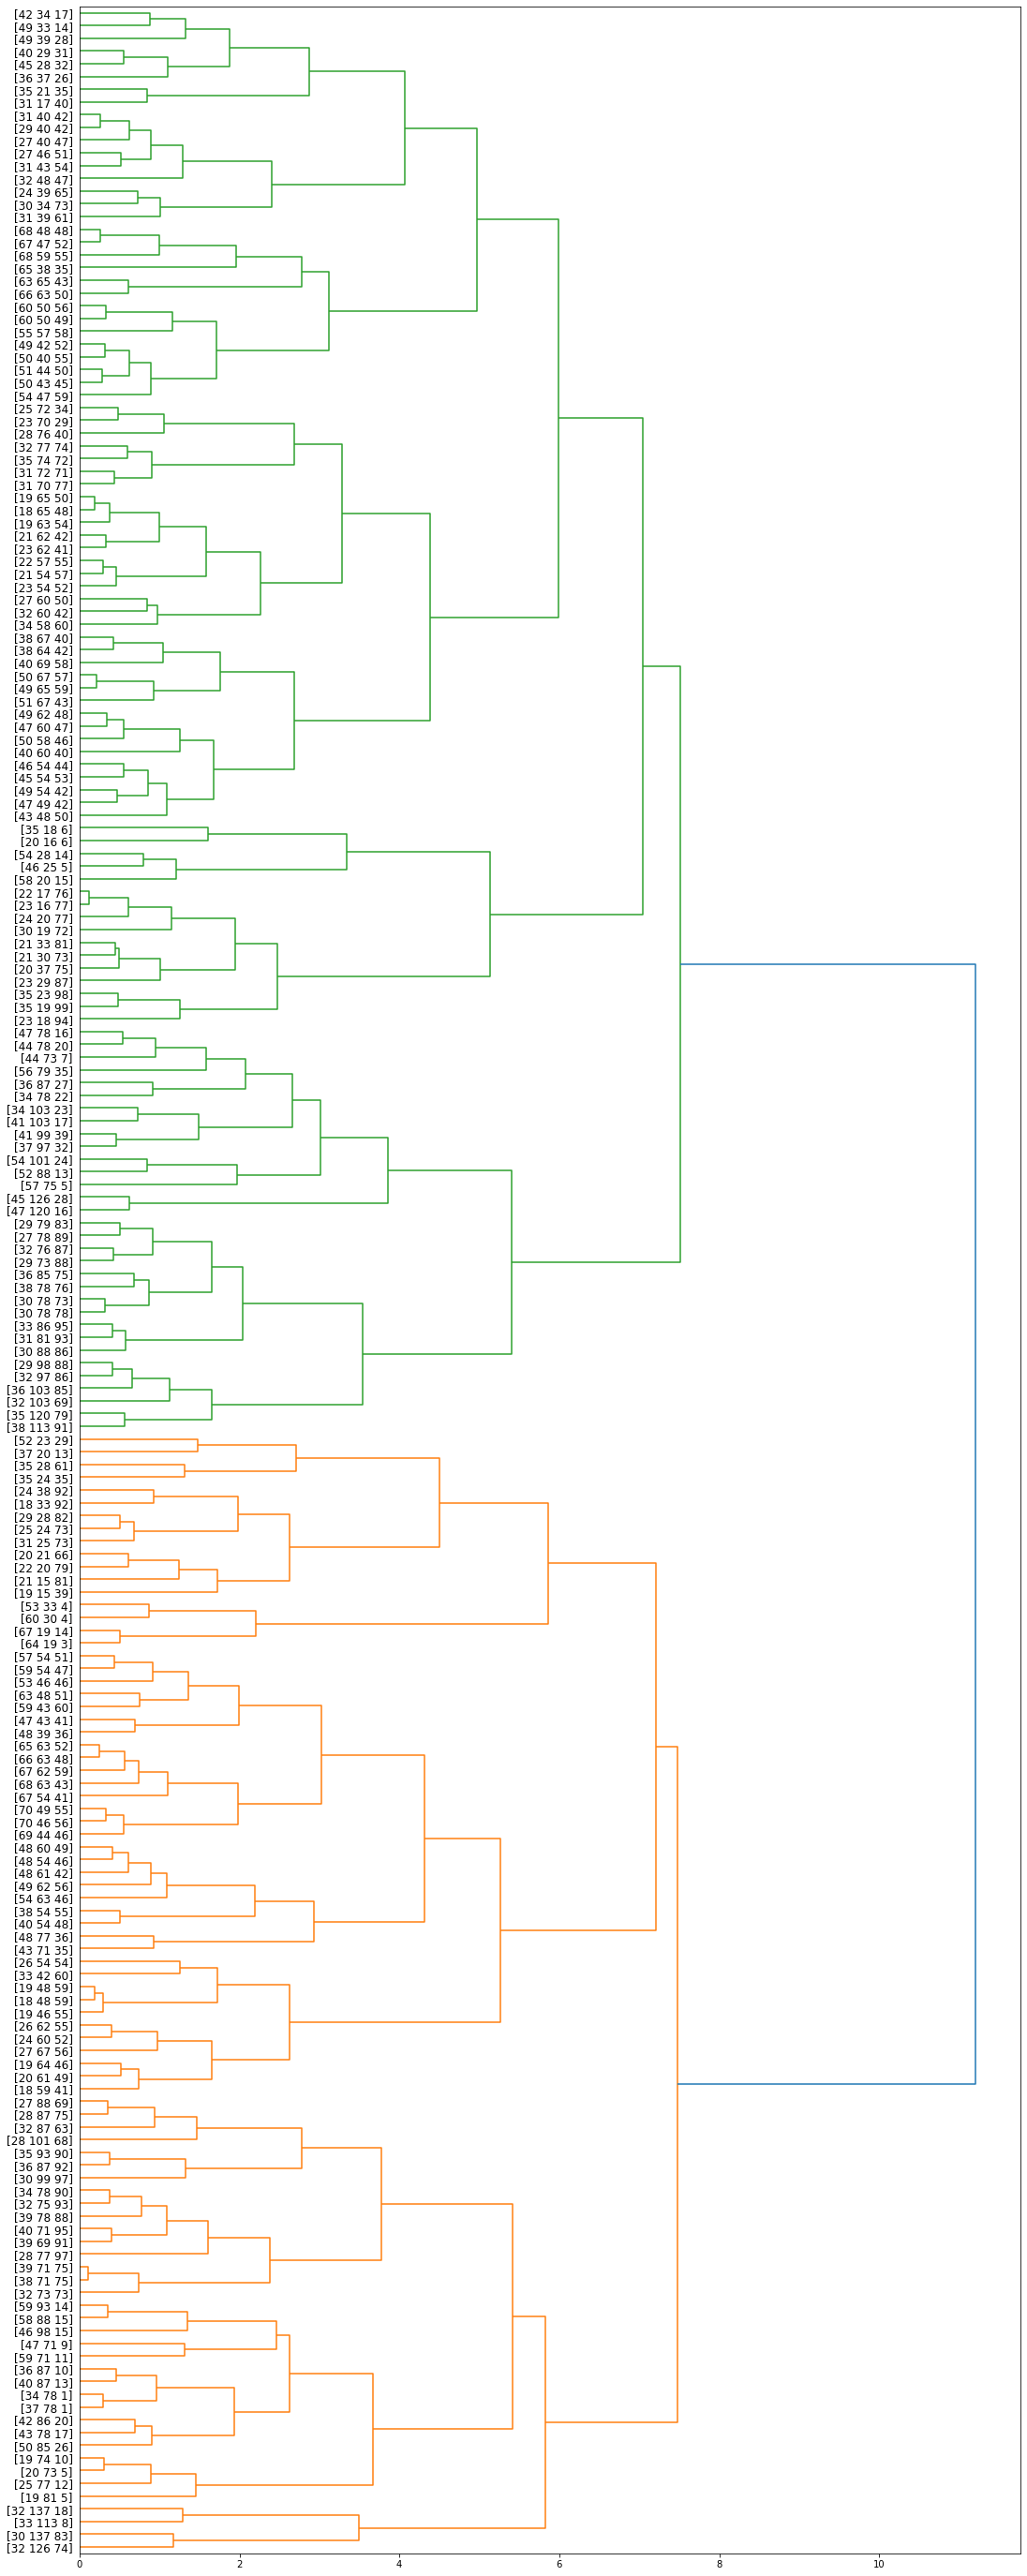

In [9]:
import pylab
fig = pylab.figure(figsize=(18,50))
def llf(id):
    return '[%s %s %s]' % (df['Age'][id], df['Annual Income (k$)'][id], int(float(df['Spending Score (1-100)'][id])) )
    
dendro = hierarchy.dendrogram(Z_using_dist_matrix,  leaf_label_func=llf, leaf_rotation=0, leaf_font_size =12, orientation = 'right')

In [10]:
model = AgglomerativeClustering(n_clusters = 6, linkage = 'complete')
model.fit(dist_matrix)

model.labels_

C:\Users\bgc\anaconda3\lib\site-packages\sklearn\cluster\_agglomerative.py:493: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)


array([1, 1, 5, 5, 0, 5, 5, 5, 1, 5, 1, 5, 5, 5, 1, 1, 0, 1, 1, 5, 1, 1,
       5, 1, 5, 1, 0, 1, 0, 5, 1, 5, 1, 1, 0, 5, 0, 0, 0, 5, 0, 1, 4, 0,
       0, 0, 0, 0, 0, 0, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 4, 4, 0, 0, 4, 4,
       0, 0, 4, 0, 4, 0, 0, 0, 4, 4, 0, 4, 0, 0, 4, 4, 4, 0, 0, 4, 0, 0,
       0, 0, 0, 4, 4, 0, 0, 4, 0, 0, 4, 4, 0, 0, 4, 4, 4, 0, 0, 4, 4, 4,
       4, 0, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 0, 3, 0, 0, 4, 3, 3, 3, 3, 3,
       0, 0, 3, 2, 2, 3, 3, 0, 2, 3, 0, 2, 3, 3, 4, 0, 2, 3, 3, 3, 2, 2,
       2, 2, 3, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 3, 3, 3, 2, 2,
       3, 3, 3, 3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3,
       3, 3], dtype=int64)

In [11]:
df['cluster_'] = model.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,5
3,4,Female,23,16,77,5
4,5,Female,31,17,40,0


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

Text(0, 0.5, 'Annual Income')

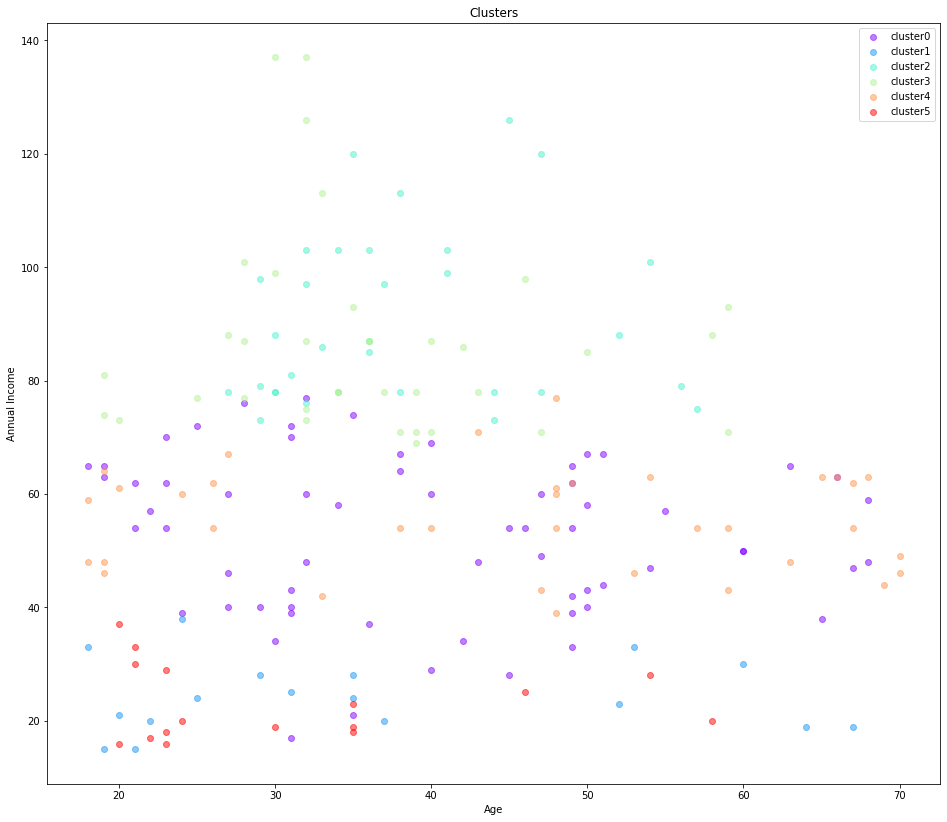

In [12]:
import matplotlib.cm as cm
n_clusters = max(model.labels_)+1
colors = cm.rainbow(np.linspace(0, 1, n_clusters))
cluster_labels = list(range(0, n_clusters))

# Create a figure of size 6 inches by 4 inches.
plt.figure(figsize=(16,14))

for color, label in zip(colors, cluster_labels):
    subset = df[df.cluster_ == label]          
    plt.scatter(subset.Age, subset['Annual Income (k$)'], c=color, label='cluster'+str(label),alpha=0.5)
#    plt.scatter(subset.horsepow, subset.mpg)
plt.legend()
plt.title('Clusters')
plt.xlabel('Age')
plt.ylabel('Annual Income')

In [13]:
customer_group=df.groupby(['cluster_'])['Age','Annual Income (k$)','Spending Score (1-100)'].mean()
customer_group

C:\Users\bgc\AppData\Local\Temp/ipykernel_11240/151338268.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  customer_group=df.groupby(['cluster_'])['Age','Annual Income (k$)','Spending Score (1-100)'].mean()


,Age,Annual Income (k$),Spending Score (1-100)
cluster_,,,
0,40.015625,52.640625,47.984375
1,36.000000,24.411765,49.411765
2,38.000000,90.593750,54.531250
3,36.055556,86.750000,47.166667
4,45.514286,55.371429,49.457143
5,30.625000,23.000000,59.687500


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

Text(0, 0.5, 'Spending Score (1-100) ')

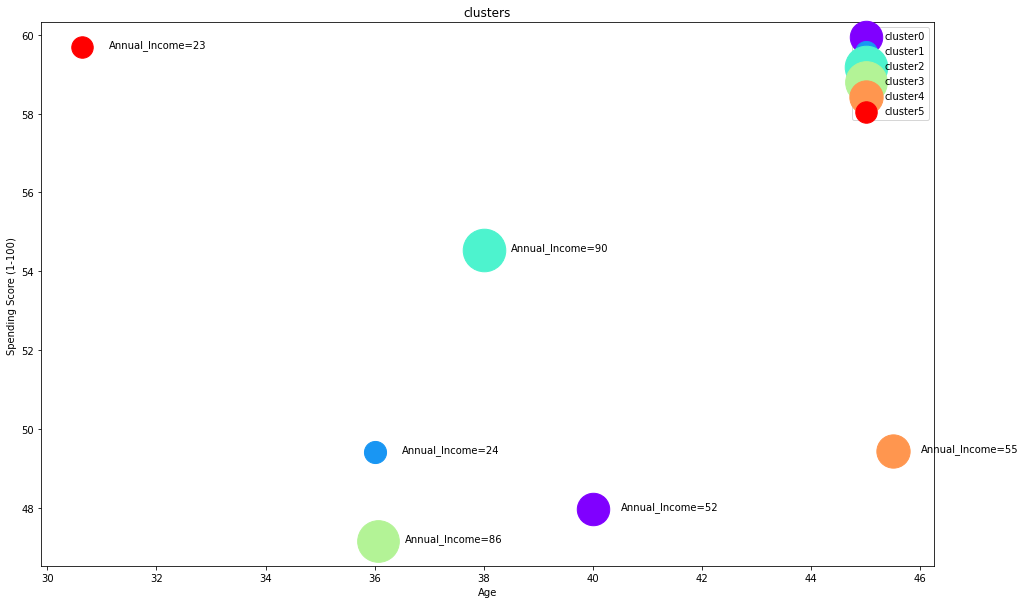

In [14]:
plt.figure(figsize=(16,10))
for color, label in zip (colors, cluster_labels):
    subset=customer_group.loc[(label,),] 
    for i in subset.index:
        plt.text(subset.loc[i][0]+0.5, subset.loc[i][2], 'Annual_Income='+str(int(subset.loc[i][1])) )
    plt.scatter(subset.Age, subset['Spending Score (1-100)'], s=subset['Annual Income (k$)']*20, c=color,label='cluster' +str(label))

plt.legend()
plt.title('clusters')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100) ')

# K-means 

In [15]:
customer='customer.csv'
df=pd.read_csv(customer)
print("shape of dataset:",df.shape)
df.head(5)

shape of dataset: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## pre-processing

In [16]:
x1 = df[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
x1[0:5]

array([[1, 'Male', 19, 15, 39],
       [2, 'Male', 21, 15, 81],
       [3, 'Female', 20, 16, 6],
       [4, 'Female', 23, 16, 77],
       [5, 'Female', 31, 17, 40]], dtype=object)

In [17]:
from sklearn import preprocessing
gender = preprocessing.LabelEncoder()
gender.fit(['Female','Male'])
x1[:,1] = gender.transform(x1[:,1]) 
x1[0:5]

array([[1, 1, 19, 15, 39],
       [2, 1, 21, 15, 81],
       [3, 0, 20, 16, 6],
       [4, 0, 23, 16, 77],
       [5, 0, 31, 17, 40]], dtype=object)

In [18]:
df['Gender']=x1[:,1]

array([[<AxesSubplot:title={'center':'CustomerID'}>,
        <AxesSubplot:title={'center':'Age'}>],
       [<AxesSubplot:title={'center':'Annual Income (k$)'}>,
        <AxesSubplot:title={'center':'Spending Score (1-100)'}>]],
      dtype=object)

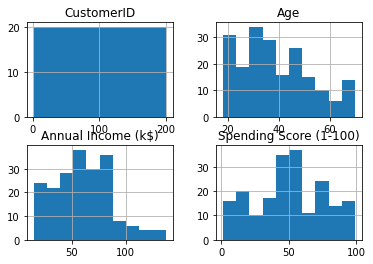

In [19]:
df.hist()

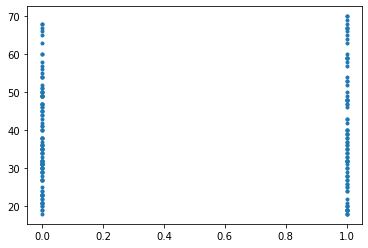

In [20]:
plt.scatter(x1[:,1],x[:,2],marker='.')

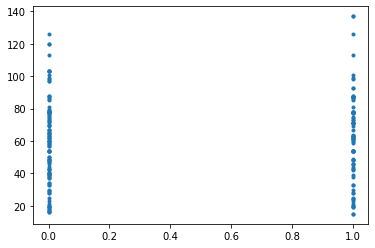

In [21]:
plt.scatter(x1[:,1],x[:,3],marker='.')

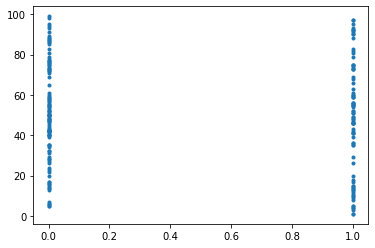

In [22]:
plt.scatter(x1[:,1],x[:,4],marker='.')

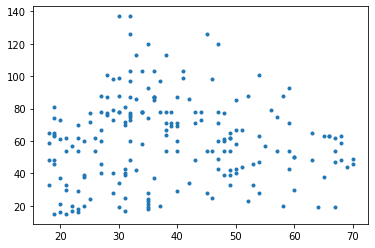

In [23]:
plt.scatter(x1[:,2],x[:,3],marker='.')

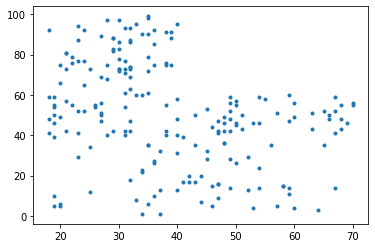

In [24]:
plt.scatter(x1[:,2],x[:,4],marker='.')

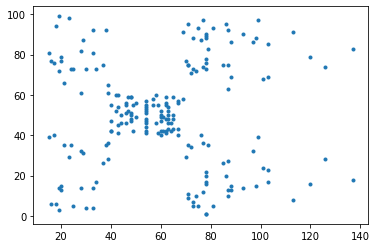

In [25]:
plt.scatter(x1[:,3],x[:,4],marker='.')

## Normalizing over the standard deviation
### StandardScaler()

In [26]:
from sklearn.preprocessing import StandardScaler
#x1=df.values[:,1:]
x1=np.nan_to_num(x1)
x1=StandardScaler().fit_transform(x)
x1

array([[-1.7234121 ,  1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.70609137,  1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-1.68877065, -0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-1.67144992, -0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-1.6541292 , -0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-1.63680847, -0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-1.61948775, -0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-1.60216702, -0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [-1.5848463 ,  1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-1.56752558, -0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [-1.55020485,  1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-1.53288413, -0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-1.5155634 , -0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-1.49824268, -0.88640526, -1.0

## Modeling

In [27]:
from sklearn.cluster import KMeans 

clusterNum = 5
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(x)
labels = k_means.labels_
print(labels)

[4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4
 0 4 0 4 0 4 0 4 0 0 0 4 4 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3]


In [28]:
df["cluster_"] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_
0,1,1,19,15,39,4
1,2,1,21,15,81,0
2,3,0,20,16,6,4
3,4,0,23,16,77,0
4,5,0,31,17,40,4


In [29]:
df.groupby('cluster_').mean()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
cluster_,,,,
0,27.851852,26.962963,28.518519,74.925926
1,162.000000,40.394737,87.000000,18.631579
2,87.971831,44.112676,56.000000,49.873239
3,162.000000,32.692308,86.538462,82.128205
4,25.120000,44.000000,27.400000,22.600000


C:\Users\bgc\AppData\Local\Temp/ipykernel_11240/3821366251.py:1: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  plt.scatter(x1[:, 3], x1[:, 4], c=labels.astype(np.float), alpha=0.5);


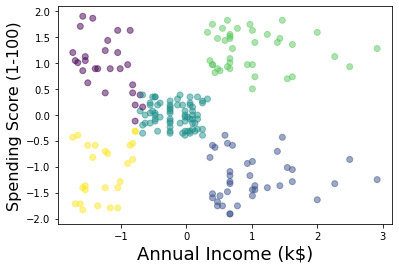

In [30]:
 
plt.scatter(x1[:, 3], x1[:, 4], c=labels.astype(np.float), alpha=0.5);
plt.xlabel('Annual Income (k$)', fontsize=18)
plt.ylabel('Spending Score (1-100)', fontsize=16)
plt.show();

## DBSCAN (Density-based) clustering

In [31]:
customer='customer.csv'
df=pd.read_csv(customer)
print("shape of dataset:",df.shape)
df.head(5)

shape of dataset: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
x2 = df[[ 'Annual Income (k$)', 'Spending Score (1-100)']].values
x2[0:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]], dtype=int64)

In [33]:
from sklearn.preprocessing import StandardScaler
x2=df[['Annual Income (k$)','Spending Score (1-100)']]
x2=np.nan_to_num(x2)
x2=StandardScaler().fit_transform(x2)
x2

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

## Modeling

In [34]:
from sklearn.cluster import DBSCAN 


db = DBSCAN(eps= 0.5, min_samples=10).fit(x2)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
labels

array([-1,  0,  1,  0, -1,  0,  1, -1,  1,  0,  1, -1,  1,  0,  1,  0, -1,
        0, -1, -1, -1,  0,  1,  0,  1,  0,  0,  0,  0,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  2,  0,  2,  0,  2,  3,  2,  3,  2,  0,  2,  3,  2,
        3,  2,  3,  2,  3,  2,  0,  2,  3,  2,  0,  2,  3,  2,  3,  2,  3,
        2,  3,  2,  3,  2,  3,  2,  0,  2,  3,  2,  3,  2,  3,  2,  3,  2,
        3,  2,  3,  2,  3,  2,  3,  2,  3,  2, -1,  2,  3,  2, -1,  2,  3,
       -1,  3, -1,  3, -1, -1, -1, -1, -1, -1, -1, -1, -1], dtype=int64)

In [35]:
realClusterNum=len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels)) 

clusterNum

5

In [36]:
unique_labels=set(labels)
unique_labels

{-1, 0, 1, 2, 3}

### Data visualization

In [37]:
#Create colors for the clusters.
colors=plt.cm.spring_r(np.linspace(0,1,len(unique_labels)))
colors

array([[1.        , 1.        , 0.        , 1.        ],
       [1.        , 0.74901961, 0.25098039, 1.        ],
       [1.        , 0.49803922, 0.50196078, 1.        ],
       [1.        , 0.24705882, 0.75294118, 1.        ],
       [1.        , 0.        , 1.        , 1.        ]])

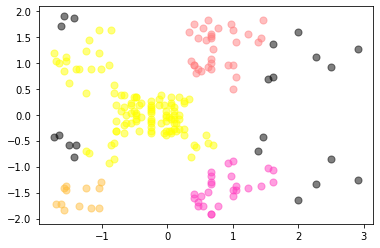

In [38]:
for k,col in zip(unique_labels,colors):
    if k==-1:
         # Black used for noise.
         col='k'

    class_member_mask=(labels==k)

    # Plot the datapoints that are clustered
    xy=x2[class_member_mask & core_samples_mask]
    plt.scatter(xy[:,0], xy[:,1], s=50 ,c=[col], marker=u'o',alpha=0.5)

    # Plot the borders
    xy=x2[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:,0] , xy[:,1], s=50, c=[col], marker=u'o', alpha=0.5)
